# Monte Carlo Option Pricing — Analysis

**Workflow:**

0. <b>RESTART THE KERNEL</b>
1. Edit `demo/study_config.json` with your option parameters
2. Run `./demo/run_study demo/study_config.json` (generates `results/*.csv`)
3. Run the cells below

In [1]:
import os, sys

# make sure we are at the project root, not inside demo/
if os.path.basename(os.getcwd()) == 'demo':
    os.chdir('..')

sys.path.insert(0, 'demo')
import utils

# --- option parameters (must match study_config.json) ---
S0    = 100.0
K     = 100.0
r     = 0.05
sigma = 0.2
T     = 1.0

# --- human-readable label shown in every plot title ---
# Edit this to describe your option (e.g. "2D basket, rho=0.3")
option_label = 'European call, S=100, K=100, σ=20%, T=1y'

conv, term, anti = utils.load_data('results')

price_bs = utils.bs_price(S0, K, r, sigma, T)
print(f'Black-Scholes analytical price: {price_bs:.4f}')
print(f'Methods in results: {sorted(conv["method"].unique())}')

Black-Scholes analytical price: 10.4506
Methods in results: ['antithetic', 'plain', 'qmc', 'qmc_cv', 'staticcv']


## 1. Distribution of terminal values

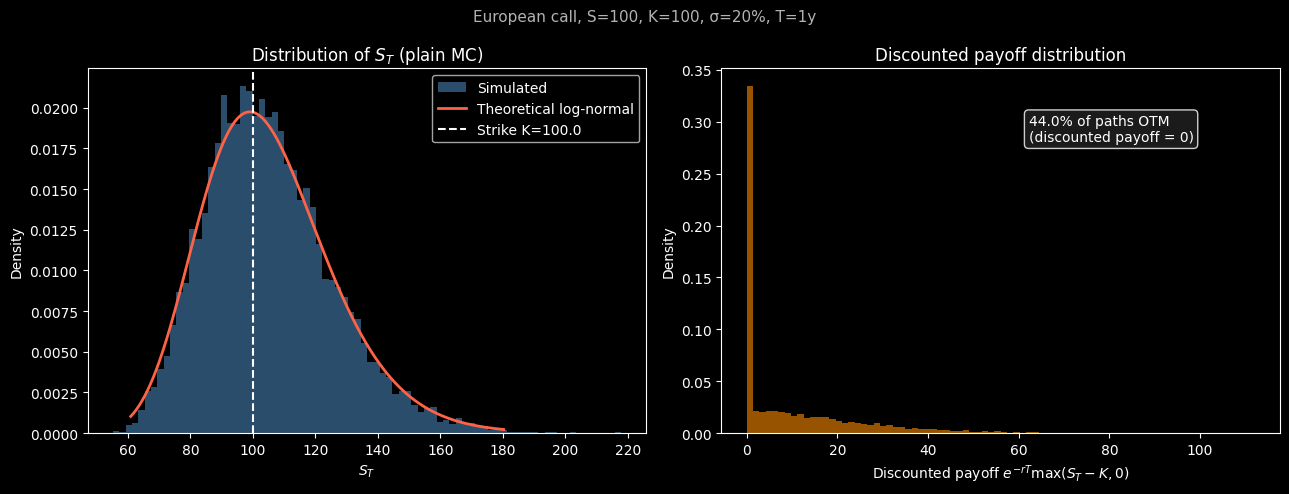

In [2]:
utils.plot_distribution(term, S0, K, r, sigma, T, option_label=option_label)

## 2. Antithetic pairing — negative correlation between paired paths

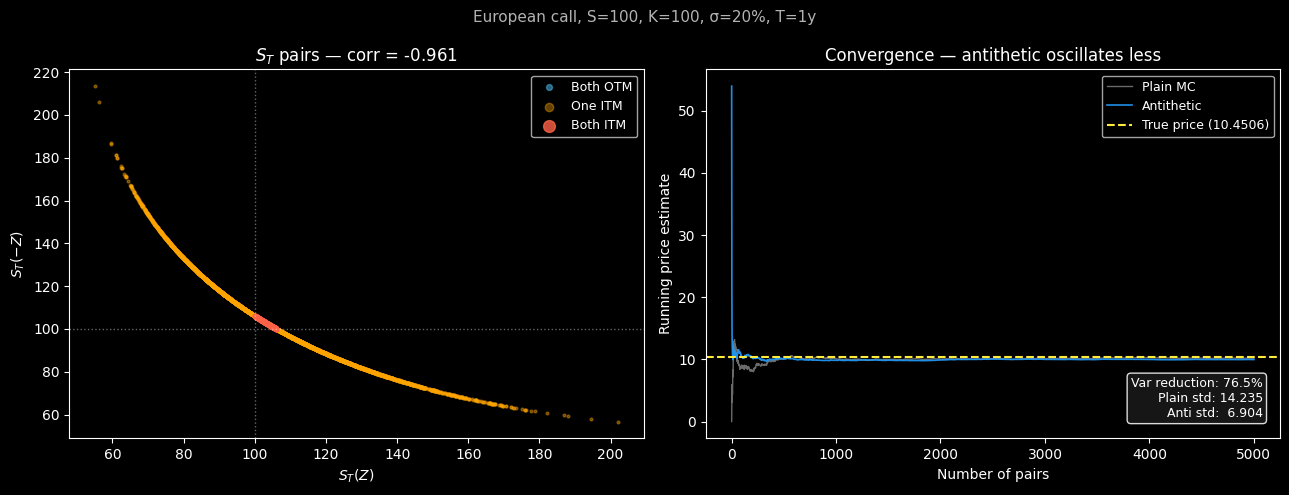

In [3]:
utils.plot_antithetic(anti, K, analytical_price=price_bs, option_label=option_label)

## 3. Price convergence vs number of paths

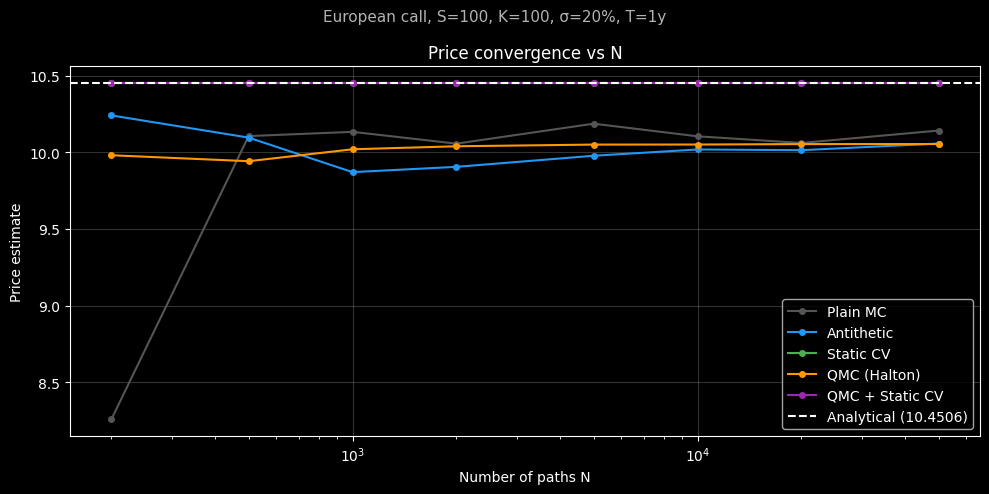

In [4]:
utils.plot_convergence(conv, analytical_price=price_bs, option_label=option_label)

## 4. CI width vs N — shows the $1/\sqrt{N}$ slope and the gain from variance reduction

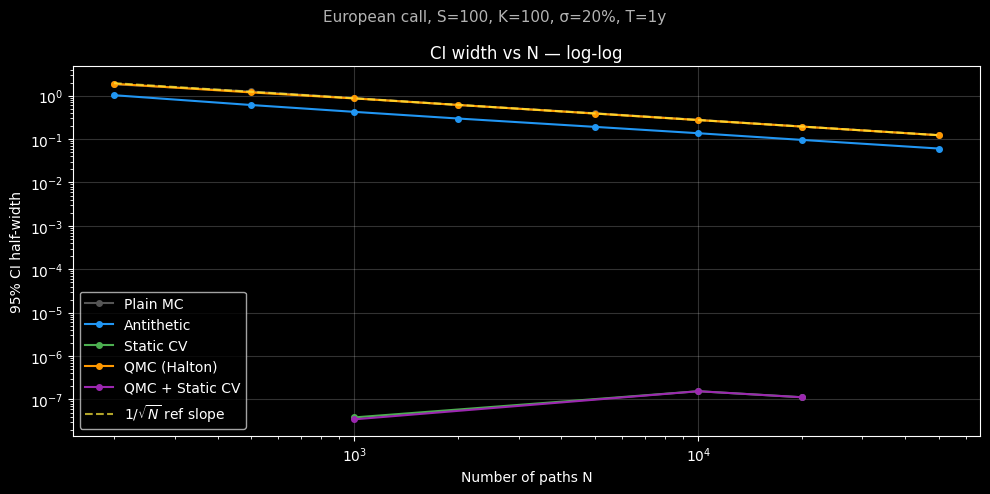

In [5]:
utils.plot_ci_vs_n(conv, option_label=option_label)

## 5. Variance by method

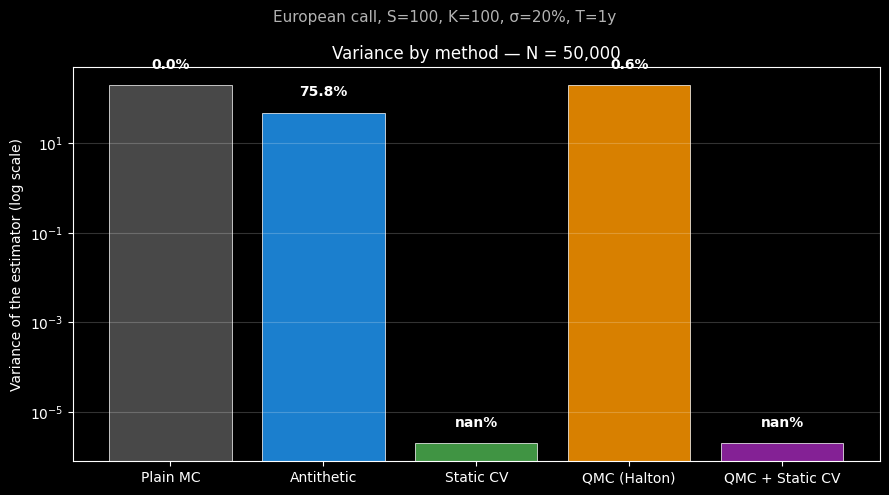

In [6]:
utils.plot_variance_bars(conv, option_label=option_label)

## 6. Required paths to achieve a target confidence interval

Target: 95% CI ≤ 0.1

         Method  Variance  Paths needed  Speedup vs plain
       Plain MC     199.3         76563               1.0
     Antithetic      47.9         18419               4.2
      Static CV       0.0             1           76563.0
   QMC (Halton)     195.7         75170               1.0
QMC + Static CV       0.0             1           76563.0


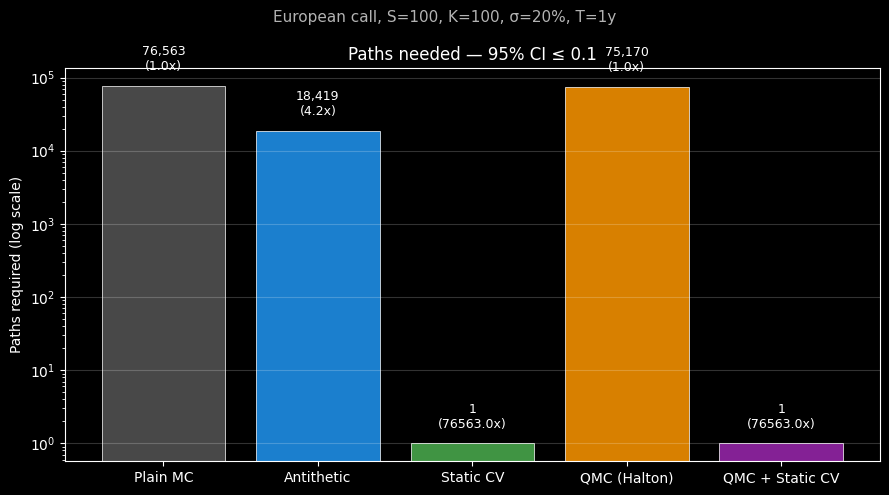

,method,label,var,n_needed,speedup
0,plain,Plain MC,1.992990e+02,76563,1.000000
1,antithetic,Antithetic,4.794535e+01,18419,4.156740
2,staticcv,Static CV,6.432450e-11,1,76563.000000
3,qmc,QMC (Halton),1.956732e+02,75170,1.018531
4,qmc_cv,QMC + Static CV,6.432450e-11,1,76563.000000


In [7]:
utils.plot_required_n(conv, target_ci=0.10, option_label=option_label)